# Notebook 04 — Gene Ontology Enrichment Analysis

We perform GO enrichment analysis on key gene lists identified in 
notebook 03 to translate gene lists into biological processes.

**Analyses:**
1. Conserved crypt SI markers → stem cell / proliferation terms
2. Conserved top villous SI markers → absorption / immune terms  
3. Region-specific tip markers → segment-specific functional terms

**Disease connection:** Conserved villus tip markers represent genes 
lost during villous atrophy in celiac disease. GO analysis reveals 
which biological processes are disrupted.

## 1. Imports and Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import gseapy as gp
import warnings
warnings.filterwarnings('ignore')

TABLES_DIR = "/home/wojmor/studies/MODEL/gut_project/results/tables"
FIGURES_DIR = "/home/wojmor/studies/MODEL/gut_project/results/figures"

import os
print("Imports done.")
print(f"gseapy version: {gp.__version__}")

Imports done.
gseapy version: 1.2.1


## 2. Load DEG Results from Notebook 03

We load the precomputed DEG tables rather than reloading the 
full AnnData object — this keeps memory usage minimal.

In [2]:
# Load layer DEGs (all SI combined)
layer_degs = pd.read_csv(f"{TABLES_DIR}/layer_degs.csv")

# Load per-region layer DEGs
layer_degs_per_region = pd.read_csv(f"{TABLES_DIR}/layer_degs_per_region.csv")

# Load region DEGs
region_degs = pd.read_csv(f"{TABLES_DIR}/region_degs.csv")

print(f"Layer DEGs: {len(layer_degs)}")
print(f"Layer DEGs per region: {len(layer_degs_per_region)}")
print(f"Region DEGs: {len(region_degs)}")

Layer DEGs: 8870
Layer DEGs per region: 33991
Region DEGs: 6406


## 3. Prepare Gene Lists

We extract the key gene lists for enrichment analysis.

In [3]:
regions = ['Duodenum', 'Jejunum1', 'Jejunum2', 'Ileum']
epi_layers = ['Crypt SI', 'Bottom villous SI', 'Top villous SI']

# --- Conserved crypt markers ---
# Genes significant in all 4 regions for Crypt SI
crypt_sets = {}
for region in regions:
    mask = (layer_degs_per_region['group'] == 'Crypt SI') & \
           (layer_degs_per_region['region'] == region)
    crypt_sets[region] = set(layer_degs_per_region[mask]['names'])

conserved_crypt = list(
    crypt_sets['Duodenum'] & crypt_sets['Jejunum1'] & 
    crypt_sets['Jejunum2'] & crypt_sets['Ileum']
)

# --- Conserved top villous markers (no mitochondrial) ---
top_sets = {}
for region in regions:
    mask = (layer_degs_per_region['group'] == 'Top villous SI') & \
           (layer_degs_per_region['region'] == region)
    top_sets[region] = set(layer_degs_per_region[mask]['names'])

conserved_top = list(
    top_sets['Duodenum'] & top_sets['Jejunum1'] & 
    top_sets['Jejunum2'] & top_sets['Ileum']
)
# Remove mitochondrial genes
conserved_top_nmt = [g for g in conserved_top if not g.startswith('mt-')]

# --- Region-specific tip markers ---
# Genes unique to each region's top villous (not in any other region)
region_specific_tip = {}
for region in regions:
    other_regions = [r for r in regions if r != region]
    other_genes = set()
    for r in other_regions:
        mask = (layer_degs_per_region['group'] == 'Top villous SI') & \
               (layer_degs_per_region['region'] == r)
        other_genes |= set(layer_degs_per_region[mask]['names'])
    
    mask = (layer_degs_per_region['group'] == 'Top villous SI') & \
           (layer_degs_per_region['region'] == region)
    this_genes = set(layer_degs_per_region[mask]['names'])
    region_specific_tip[region] = list(this_genes - other_genes)

print(f"Conserved crypt markers: {len(conserved_crypt)}")
print(f"Conserved top villous markers (no mt): {len(conserved_top_nmt)}")
print(f"\nRegion-specific tip markers:")
for region, genes in region_specific_tip.items():
    print(f"  {region}: {len(genes)}")

Conserved crypt markers: 646
Conserved top villous markers (no mt): 2369

Region-specific tip markers:
  Duodenum: 210
  Jejunum1: 9
  Jejunum2: 282
  Ileum: 975


## 4. GO Enrichment Analysis

We query the Enrichr database for each gene list using three 
GO databases:
- **GO Biological Process** — what processes the genes are involved in
- **GO Molecular Function** — what molecular activities they perform
- **GO Cellular Component** — where in the cell they act

We use mouse gene symbols directly since our data is from mouse.

In [4]:
def run_enrichr(gene_list, description, gene_sets=None):
    """Run Enrichr enrichment analysis on a gene list."""
    if gene_sets is None:
        gene_sets = ['GO_Biological_Process_2023',
                     'GO_Molecular_Function_2023',
                     'GO_Cellular_Component_2023']
    
    if len(gene_list) == 0:
        print(f"Skipping {description} — empty gene list")
        return None
    
    results = gp.enrichr(
        gene_list=gene_list,
        gene_sets=gene_sets,
        organism='mouse',
        outdir=None,  # don't save raw files
        cutoff=0.05
    )
    
    df = results.results
    df['analysis'] = description
    
    # Filter significant results
    sig = df[df['Adjusted P-value'] < 0.05].copy()
    sig = sig.sort_values('Adjusted P-value')
    
    print(f"{description}: {len(sig)} significant terms")
    return sig

print("Function defined.")

Function defined.


## 5. Run Enrichment on Key Gene Lists

In [5]:
# Run GO analysis on all key gene lists
print("Running GO enrichment — this requires internet connection...")
print("Querying Enrichr API...\n")

# 1. Conserved crypt markers
go_crypt = run_enrichr(
    conserved_crypt, 
    "Conserved Crypt SI markers"
)

# 2. Conserved top villous markers
go_top = run_enrichr(
    conserved_top_nmt,
    "Conserved Top Villous SI markers"
)

# 3. Region-specific tip markers
go_region_tip = {}
for region in regions:
    if len(region_specific_tip[region]) > 10:  # skip if too few genes
        go_region_tip[region] = run_enrichr(
            region_specific_tip[region],
            f"{region}-specific tip markers"
        )

print("\nAll GO analyses complete.")

Running GO enrichment — this requires internet connection...
Querying Enrichr API...

Conserved Crypt SI markers: 387 significant terms
Conserved Top Villous SI markers: 645 significant terms
Duodenum-specific tip markers: 0 significant terms
Jejunum2-specific tip markers: 2 significant terms
Ileum-specific tip markers: 76 significant terms

All GO analyses complete.


## 6. Visualize GO Results

We plot the top enriched GO Biological Process terms for each 
analysis as horizontal bar plots — the standard visualization 
for enrichment results.

In [6]:
def plot_go_terms(df, title, n_terms=15, color='steelblue', ax=None):
    """Plot top GO terms as horizontal bar plot."""
    # Filter to Biological Process only for clarity
    bp = df[df['Gene_set'].str.contains('Biological_Process')].copy()
    
    if len(bp) == 0:
        print(f"No Biological Process terms for {title}")
        return
    
    # Take top n terms by adjusted p-value
    top = bp.nsmallest(n_terms, 'Adjusted P-value').copy()
    
    # Clean term names (remove GO ID)
    top['Term_clean'] = top['Term'].str.replace(r'\(GO:\d+\)', '', regex=True).str.strip()
    
    # -log10 p-value for x axis
    top['neg_log_p'] = -np.log10(top['Adjusted P-value'])
    
    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.barh(
        range(len(top)), 
        top['neg_log_p'].values,
        color=color, alpha=0.8, edgecolor='black', linewidth=0.3
    )
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(
        [t[:60] + '...' if len(t) > 60 else t 
         for t in top['Term_clean'].values],
        fontsize=8
    )
    ax.invert_yaxis()
    ax.set_xlabel('-log10(adjusted p-value)')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axvline(x=-np.log10(0.05), color='red', 
               linestyle='--', alpha=0.5, label='p=0.05')
    
    return ax

print("Plot function defined.")

Plot function defined.


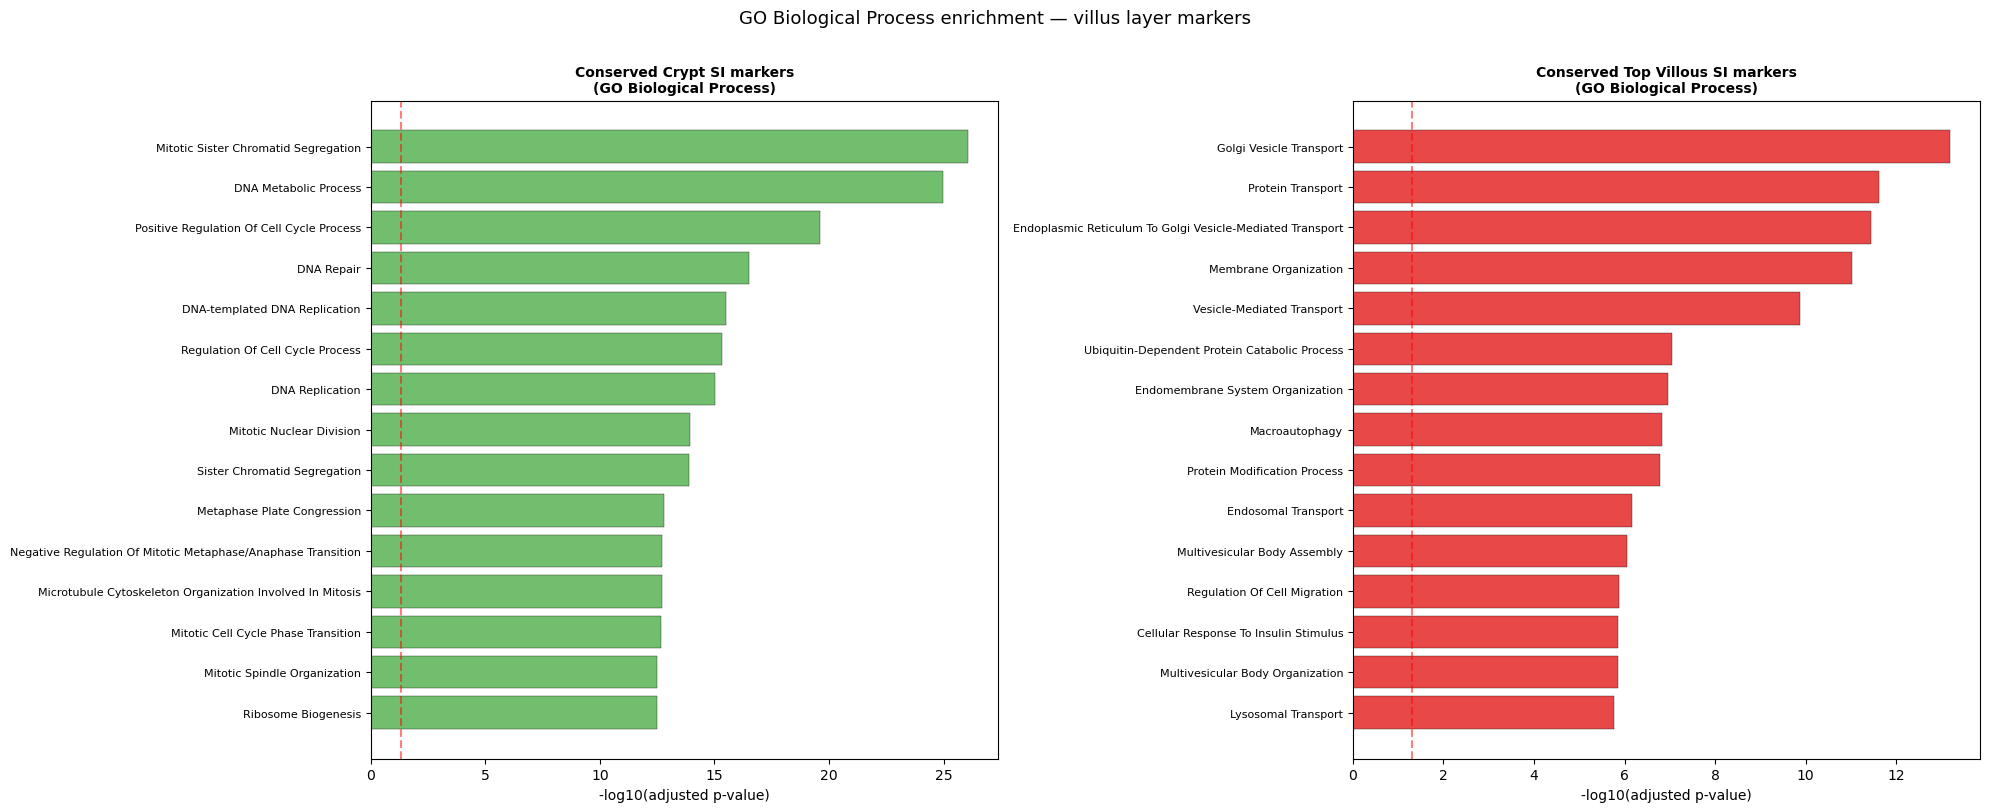

Figure saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Panel A: Conserved crypt markers
plot_go_terms(
    go_crypt,
    'Conserved Crypt SI markers\n(GO Biological Process)',
    n_terms=15,
    color='#4daf4a',
    ax=axes[0]
)

# Panel B: Conserved top villous markers
plot_go_terms(
    go_top,
    'Conserved Top Villous SI markers\n(GO Biological Process)',
    n_terms=15,
    color='#e41a1c',
    ax=axes[1]
)

plt.suptitle('GO Biological Process enrichment — villus layer markers',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_go_crypt_vs_top_villous.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

# 7. Ileum-Specific Villus Tip GO Terms

The ileum has 975 region-specific tip markers — far more than 
any other segment. GO analysis reveals what makes the ileal 
villus tip transcriptionally unique.

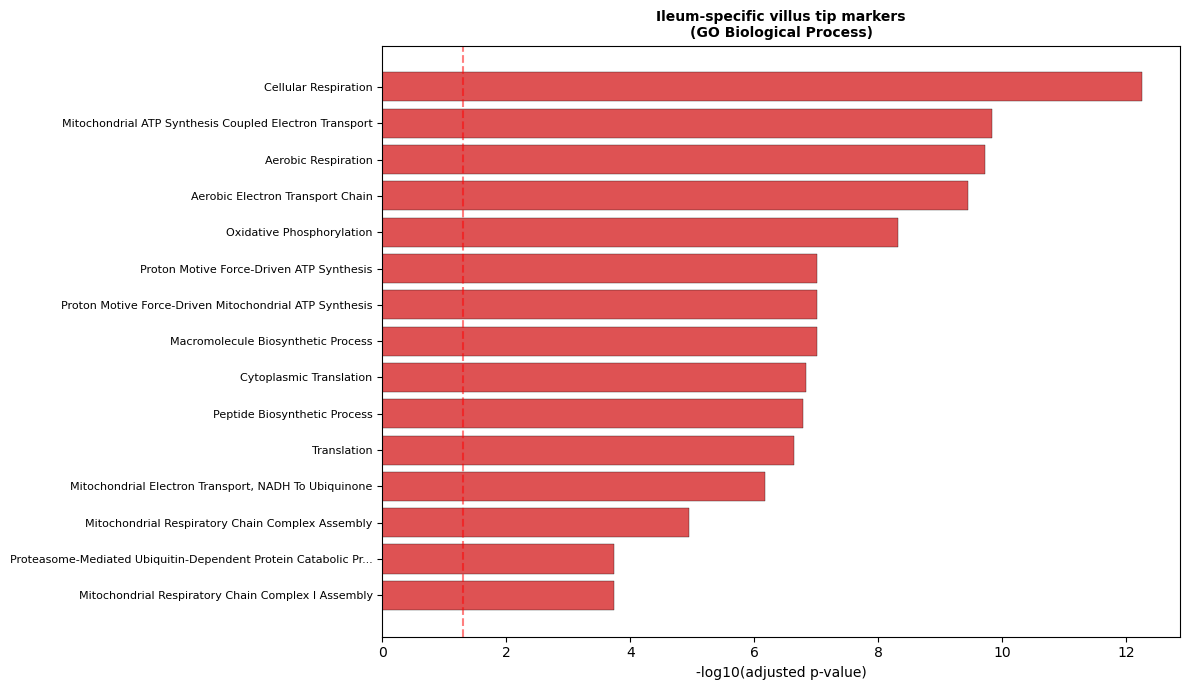

Figure saved.


In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

plot_go_terms(
    go_region_tip['Ileum'],
    'Ileum-specific villus tip markers\n(GO Biological Process)',
    n_terms=15,
    color='#d62728',
    ax=ax
)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_go_ileum_specific_tip.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## 8. Save GO Results

In [9]:
# Save all GO results to tables
go_crypt.to_csv(f"{TABLES_DIR}/go_conserved_crypt.csv", index=False)
go_top.to_csv(f"{TABLES_DIR}/go_conserved_top_villous.csv", index=False)

if 'Ileum' in go_region_tip and go_region_tip['Ileum'] is not None:
    go_region_tip['Ileum'].to_csv(
        f"{TABLES_DIR}/go_ileum_specific_tip.csv", index=False)

print("GO results saved.")
print(f"\nFiles saved to {TABLES_DIR}/")

GO results saved.

Files saved to /home/wojmor/studies/MODEL/gut_project/results/tables/


## 9. Summary — GO Analysis Interpretation

Key findings from GO enrichment:

| Gene list | Top GO terms | Biological interpretation |
|---|---|---|
| Conserved Crypt SI | Cell cycle, DNA replication, Mitosis | Universal stem cell / proliferation program |
| Conserved Top Villous SI | Vesicle transport, Golgi, Secretory pathway | Active secretion of chylomicrons and mucus |
| Ileum-specific tip | Oxidative phosphorylation, Cellular respiration | High energy demand for ileum-specific transport |
| Duodenum-specific tip | No enrichment | Novel/unannotated functions |

**Celiac disease connection:**
The conserved top villous program (vesicle transport, secretory pathway) 
represents the functional identity that is lost during villous atrophy. 
The ileum-specific oxidative phosphorylation enrichment suggests the 
ileum may be particularly vulnerable to energy disruption during 
intestinal inflammation.

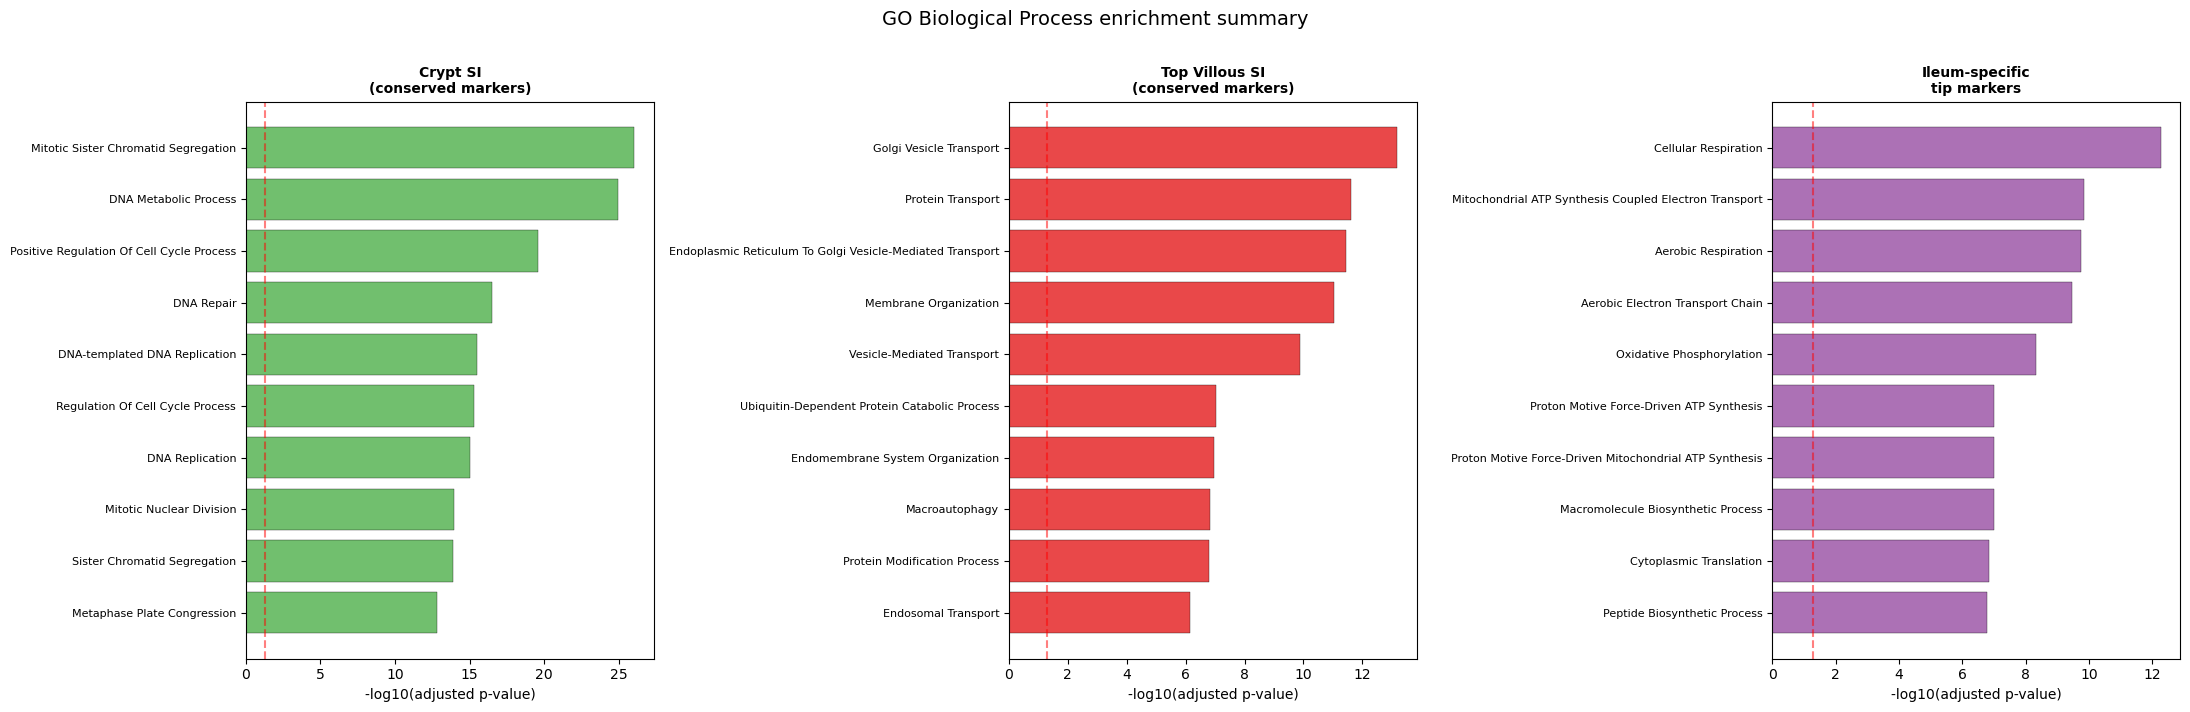

Summary figure saved.


In [10]:
# Final summary figure - combine key GO terms from all analyses
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

plot_go_terms(go_crypt, 
              'Crypt SI\n(conserved markers)',
              n_terms=10, color='#4daf4a', ax=axes[0])

plot_go_terms(go_top,
              'Top Villous SI\n(conserved markers)', 
              n_terms=10, color='#e41a1c', ax=axes[1])

plot_go_terms(go_region_tip['Ileum'],
              'Ileum-specific\ntip markers',
              n_terms=10, color='#984ea3', ax=axes[2])

plt.suptitle('GO Biological Process enrichment summary',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_go_summary.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Summary figure saved.")